# Exploratory Data Analysis of the UCI Heart Disease Dataset

# Introduction

Heart disease remains one of the leading causes of death worldwide, making the identification of risk factors and clinical indicators an important area of study. The goal of this project is to explore the UCI Heart Disease dataset and investigate which demographic characteristics, symptoms, and clinical measurements appear to be associated with heart disease severity.

To accomplish this, the dataset was cleaned and analyzed using Python and Pandas. Missing values were examined and handled appropriately before conducting exploratory data analysis (EDA). Several variables, including sex, chest pain type, exercise-induced angina, blood pressure, cholesterol, maximum heart rate, and exercise stress test measurements, were evaluated to identify patterns and relationships with heart disease severity.

_________________________________________________

# Asking Questions
- Q1: Does heart disease severity differ between males and females?
- Q2: Which chest pain types are most strongly associated with heart disease?
- Q3: Is exercise-induced angina related to heart disease severity?
- Q4: How does heart disease severity vary by ST segment slope?
- Q5: Which clinical measurements appear most strongly associated with heart disease severity?
- Q6: Which numeric variables exhibit the strongest relationships with heart disease severity?

The findings from this analysis provide insight into the factors that may be most closely associated with heart disease severity within this dataset.

The objective of this project is not to build a predictive model, but rather to perform exploratory data analysis and identify variables that appear most strongly associated with heart disease severity.

# Dataset Overview

The UCI Heart Disease dataset contains 920 patient records and includes demographic information, symptoms, clinical measurements, exercise stress test results, and heart disease diagnoses.

Key characteristics of the dataset:

- 920 patient observations
- Patient ages range from 28 to 77 years
- Average age: 53.5 years
- 726 male patients (78.9%)
- 194 female patients (21.1%)

The target variable used throughout this analysis is `num`, which represents heart disease severity:

- 0 = No heart disease
- 1-4 = Increasing levels of heart disease severity

# Preparing the Environment

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import CSV
heart_disease = pd.read_csv('/kaggle/input/datasets/eunicesanmartinez/heart-disease/heart_disease_uci.csv')

# Assess Data
In this step, we explore the dataset and get basic information.

In [4]:
# View dimensions of the DataFrame
heart_disease.shape

(920, 16)

In [5]:
# View structural overview of DataFrame
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [32]:
# View summary statistics for every numeric column
heart_disease.describe()

,id,age,trestbps,chol,thalch,oldpeak,num,slope_missing,thal_missing,has_disease
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.00000,920.000000,920.000000
mean,460.500000,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652,0.33587,0.528261,0.553261
std,265.725422,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693,0.47255,0.499472,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.00000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000,0.00000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000,1.00000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000,1.00000,1.000000,1.000000


In [7]:
# View first 5 rows
heart_disease.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
# Returns summary statistics for age column
heart_disease['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

**Finding:** The dataset contains 920 patient records. The average patient age is 53.5 years, with ages ranging from 28 to 77 years. 

In [9]:
# Counts number of times each unique value appears in sex column
heart_disease['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

**Finding:** The dataset is predominantly male (726 patients, 78.9%) with 194 female patients (21.1%).

In [10]:
# Counts number of patients in each heart severity category
heart_disease['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

**Finding:** Approximately 44.7% of patients had no diagnosed heart disease, while 55.3% exhibited some level of heart disease severity.

# Handle Duplicates

In [11]:
# Check number of duplicate rows in the DataFrame
heart_disease.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset.

# Handle Missing Values 
First, the percentage of missingness will be calculated for each variable in the dataset.

In [12]:
# Calculates percentage of missing values in each column
heart_disease.isna().sum() / len(heart_disease) * 100

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

The variables *trestbps*, *chol*, *thalch*, *oldpeak*, *restecg*, *fbs*, and *exang* had less than 10% missingness. These columns were imputed using median (numeric) or mode (categorical) values. Given the small proportion of missing observations, this approach preserved sample size while minimizing distortion of the original distributions.

In [13]:
# Perform median imputation on numeric columns trestbps, chol, thalch, oldpeak with less than 10% missingness
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
heart_disease[num_cols] = heart_disease[num_cols].fillna(heart_disease[num_cols].median())

# Perform mode imputation for multiple categorical columns restecg, fbs, exang with less than 10% missingness
cat_cols = ['restecg', 'fbs', 'exang']
for col in cat_cols:
    heart_disease[col] = heart_disease[col].fillna(heart_disease[col].mode()[0])

/tmp/ipykernel_58/2901096158.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_disease[col] = heart_disease[col].fillna(heart_disease[col].mode()[0])


The *slope* variable, which contained 33% missingness, was retained and imputed due to its potential clinical relevance. 

In [14]:
# Create a missing-value indicator feature for the slope column
heart_disease['slope_missing'] = heart_disease['slope'].isna().astype(int)

# Replace missing values in the slope column with the mode of the slope category
heart_disease['slope'] = heart_disease['slope'].fillna(heart_disease['slope'].mode()[0])

The *thal* variable contained 53% missingness and was retained with imputation for exploratory purposes.

In [15]:
# Create thal_missing column to identify records where original thal value was missing 
heart_disease['thal_missing'] = heart_disease['thal'].isna().astype(int)

# Replace missing values in the slope column with the mode of the thal column
heart_disease['thal'] = heart_disease['thal'].fillna(heart_disease['thal'].mode()[0])

# Drop Column

The *ca* variable contained approximately 66% missing values and was removed from analysis due to insufficient data quality. 

In [16]:
# Drop ca variable from the DataFrame
heart_disease = heart_disease.drop(columns=['ca'])

In [17]:
# Re-check number of missing values in each column 
heart_disease.isna().sum()

id               0
age              0
sex              0
dataset          0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalch           0
exang            0
oldpeak          0
slope            0
thal             0
num              0
slope_missing    0
thal_missing     0
dtype: int64

# Exploratory Data Analysis
# Q1: Does heart disease severity differ between males and females?

In [18]:
# Groups patients by sex to compare average heart disease severity
sex_mean = (heart_disease.groupby('sex')['num'].mean().reset_index())
print(sex_mean)
print('----------------------------------------')

# Examine heart disease severity levels distributed among males and females 
print(heart_disease.groupby(['sex', 'num']).size())

      sex      num
0  Female  0.42268
1    Male  1.14876
----------------------------------------
sex     num
Female  0      144
        1       30
        2       10
        3        8
        4        2
Male    0      267
        1      235
        2       99
        3       99
        4       26
dtype: int64


In [19]:
# Calculate the percentage of males and females with heart disease
heart_disease['has_disease'] = (heart_disease['num'] > 0).astype(int)

pd.crosstab(
    heart_disease['sex'],
    heart_disease['has_disease'],
    normalize='index'
) * 100

has_disease,0,1
sex,,
Female,74.226804,25.773196
Male,36.776860,63.223140


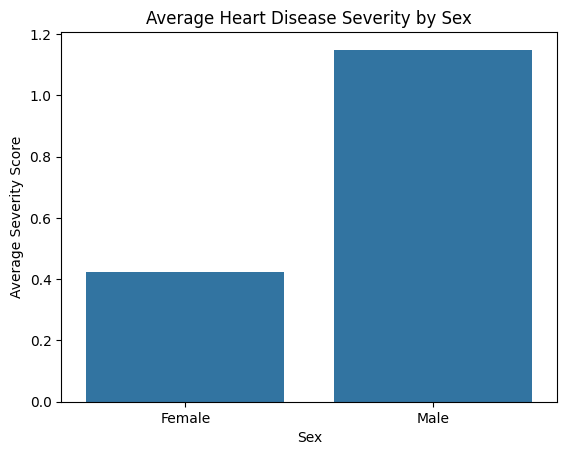

In [20]:
# Visualize average heart disease severity for each sex
sns.barplot(data=sex_mean, x='sex', y='num')
plt.title('Average Heart Disease Severity by Sex')
plt.ylabel('Average Severity Score')
plt.xlabel('Sex')
plt.show()

**Finding:** Male patients had a higher average heart disease severity score (1.15) than female patients (0.42). Additionally, males were more frequently represented in the more severe disease categories (2-4), whereas the majority of female patients had no diagnoses heart disease (num = 0). These results suggest that sex may be an important risk factor in this dataset.


# Q2: Which chest pain types are most strongly associated with heart disease?

In [21]:
# Compare average heart disease severity across chest pain types
cp_mean = heart_disease.groupby('cp')['num'].mean().reset_index()
print(cp_mean)
print('---------------------------------------')
pd.crosstab(
    heart_disease['cp'], heart_disease['num']
)

                cp       num
0     asymptomatic  1.443548
1  atypical angina  0.183908
2      non-anginal  0.661765
3   typical angina  0.717391
---------------------------------------


num,0,1,2,3,4
cp,,,,,
asymptomatic,104,197,89,83,23
atypical angina,150,19,2,3,0
non-anginal,131,37,14,18,4
typical angina,26,12,4,3,1


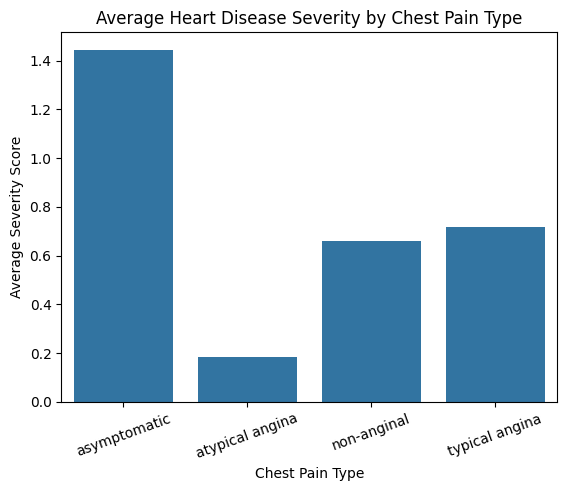

In [22]:
# Visualize average heart disease severity by chest pain type
sns.barplot(data=cp_mean, x='cp', y='num')
plt.title('Average Heart Disease Severity by Chest Pain Type')
plt.ylabel('Average Severity Score')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation=20)
plt.show()

**Finding:** Patients with asymptomatic chest pain had the highest average heart disease severity score (1.44), substantially higher than all other chest pain categories. This suggests that asymptomatic chest pain is strongly associated with heart disease severity in this dataset. Patients with atypical angina and non-anginal chest pain showed moderate associations with heart disease. Using the crosstab, the asymptomatic chest pain group contained the largest concentration of patients in the higher severity categories (2-4), whereas most patients with atypical angina had no diagnosed heart disease. This suggests chest pain type may be an important indicator of heart disease severity.

# Q3: Is exercise-induced angina related to heart disease severity?

In [23]:
# Compare average heart disease severity between patients with and without exercise-induced angina
print(heart_disease.groupby('exang')['num'].mean())

pd.crosstab(
    heart_disease['exang'],
    heart_disease['num'],
    normalize='index'
) * 100

exang
False    0.691252
True     1.522255
Name: num, dtype: float64


num,0,1,2,3,4
exang,,,,,
False,61.063465,20.583190,8.747856,7.375643,2.229846
True,16.320475,43.026706,17.210682,18.991098,4.451039


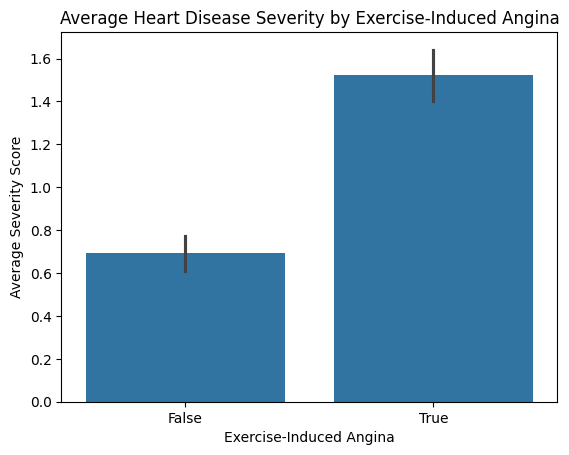

In [24]:
# Visualize average heart disease severity by exercise-induced angina status
sns.barplot(
    data=heart_disease,
    x='exang',
    y='num'
)

plt.title('Average Heart Disease Severity by Exercise-Induced Angina')
plt.xlabel('Exercise-Induced Angina')
plt.ylabel('Average Severity Score')

plt.show()

**Finding:** Patients who experienced exercise-induced angina had a substantially higher average heart disease severity score (1.52) compared to patients who did not experience exercise-induced angina (0.69). 
The large difference in average severity scores suggests that exercise-induced angina may be an important indicator of underlying heart disease. 
Patients reporting exercise-induced angina tended to have more severe heart disease than those without exercise-induced angina.
The strong difference between groups suggests that exercise-induced angina may be a useful feature for predicting heart disease severity.

# Q4: How does heart disease severity vary by ST segment slope?

In [25]:
# Compare average heart disease severity and severity distributions across ST seg,emt slope categories
print(heart_disease.groupby('slope')['num'].mean().reset_index())

pd.crosstab(
    heart_disease['slope'], heart_disease['num']
)

         slope       num
0  downsloping  1.746032
1         flat  1.018349
2    upsloping  0.689655


num,0,1,2,3,4
slope,,,,,
downsloping,14,15,14,13,7
flat,272,211,76,77,18
upsloping,125,39,19,17,3


**Finding:** Patients with a downsloping ST segment exhibited the highest average heart disease severity, while patients with an upsloping ST segment exhibited the lowest. This suggests that ST segment slope may be an important clinical indicator of heart disease severity.

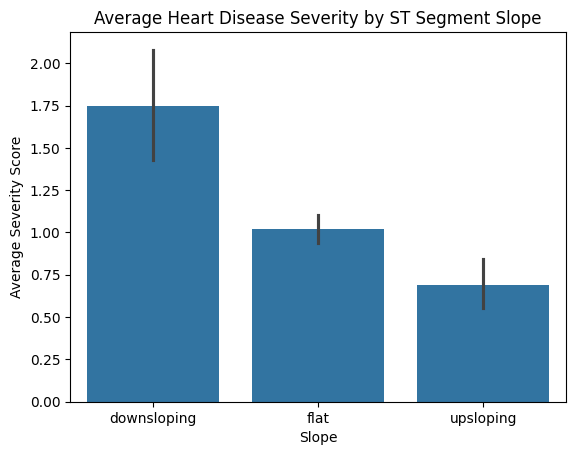

In [26]:
# Visualize average heart disease severity across ST segment slope categories
sns.barplot(
    data=heart_disease, 
    x='slope', 
    y='num'
)

plt.title('Average Heart Disease Severity by ST Segment Slope')
plt.ylabel('Average Severity Score')
plt.xlabel('Slope')

plt.show()

**Finding:** The distribution of heart disease severity differed across ST segment slope categories. Patients with a downsloping slope were more frequently observed in the heart disease categories (1-4), while patients with an upsloping slope were more likely to have no diagnosed heart disease (num = 0). This suggests that ST segment slope may be associated with heart disease severity.

# Q5: Which clinical measurements appear most strongly associated with heart disease severity?

In [27]:
# Analyze how clinical measurements change with heart disease severity 
heart_disease.groupby('num')[['trestbps','chol','thalch', 'oldpeak']].mean()

,trestbps,chol,thalch,oldpeak
num,,,,
0,129.917275,227.678832,148.372263,0.422384
1,132.720755,195.988679,131.475472,0.972830
2,133.348624,145.311927,129.394495,1.290826
3,135.289720,160.308411,122.869159,1.419626
4,137.785714,193.250000,128.714286,2.178571


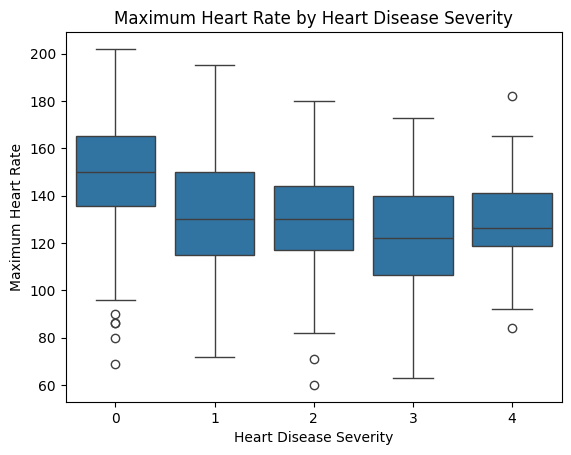

In [28]:
# Compare maximum heart rate distributions across heart disease severity categories
sns.boxplot(
    data=heart_disease,
    x='num',
    y='thalch'
)

plt.title('Maximum Heart Rate by Heart Disease Severity')
plt.xlabel('Heart Disease Severity')
plt.ylabel('Maximum Heart Rate')

plt.show()

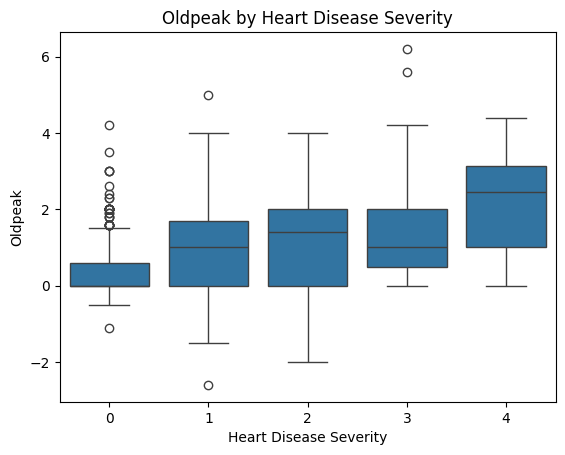

In [29]:
# Analyze how clinical measurements change with heart disease severity 
sns.boxplot(
    data=heart_disease,
    x='num',
    y='oldpeak'
)

plt.title('Oldpeak by Heart Disease Severity')
plt.xlabel('Heart Disease Severity')
plt.ylabel('Oldpeak')

plt.show()

**Finding:** Oldpeak exhibited the strongest positive relationship with heart disease severity. Average values increased consistently from 0.42 among patients without heart disease to 2.18 among patients with stage 4 disease. In contrast, maximum heart rate (thalch) decreased as disease severity increased, while resting blood pressure (trestbps) showed only a modest upward trend. Cholesterol levels did not demonstrate a consistent relationship with disease severity. These results suggest that oldpeak and thalch may be among the most informative clinical measurements in this dataset. 

# Q6: Which numeric variables exhibit the strongest relationships with heart disease severity?

In [30]:
# Identify which numeric variables are most strongly associated with heart disease severity 
numeric_cols = ['age','trestbps','chol','thalch','oldpeak','num']

corr_matrix = heart_disease[numeric_cols].corr()
print(corr_matrix)

               age  trestbps      chol    thalch   oldpeak       num
age       1.000000  0.230784 -0.086010 -0.349715  0.233550  0.339596
trestbps  0.230784  1.000000  0.089484 -0.104747  0.161217  0.113178
chol     -0.086010  0.089484  1.000000  0.226047  0.047454 -0.230539
thalch   -0.349715 -0.104747  0.226047  1.000000 -0.149401 -0.349173
oldpeak   0.233550  0.161217  0.047454 -0.149401  1.000000  0.411588
num       0.339596  0.113178 -0.230539 -0.349173  0.411588  1.000000


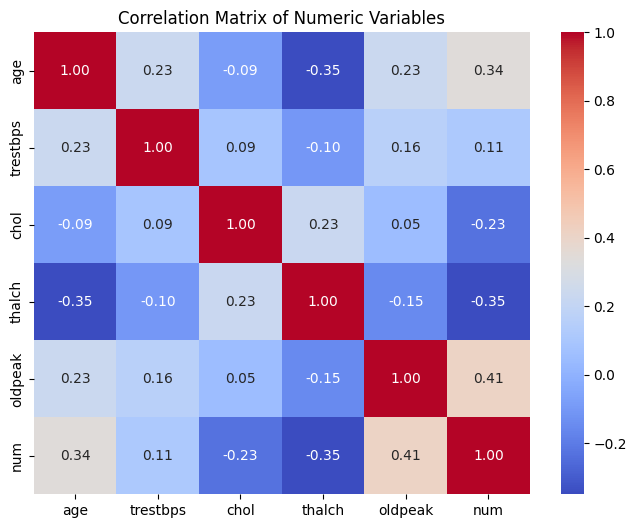

In [31]:
# Visualize correlations between numeric variables
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numeric Variables')
plt.show()

**Finding:** 
* *Age* demonstrated a moderate positive correlation with heart disease severity (r = 0.34), indicating that older patients tended to have more severe heart disease.

* Resting blood pressure (trestbps) showed only a weak relationship with heart disease severity (r = 0.11).

* Cholesterol (*chol*) displayed a weak negative correlation with heart disease severity (r = -0.23). Contrary to expectations, higher cholesterol levels were not associated with increased heart disease severity in this dataset.

* Maximum heart rate (*thalch*) showed a moderate negative correlation with heart disease severity (r = -0.35), indicating that patients with more severe heart disease tended to achieve lower maximum heart rates.
  
* *Oldpeak* exhibited the strongest positive correlation with heart disease severity (r = 0.41), suggesting that higher oldpeak values are associated with more severe heart disease.

## Key Findings

- Male patients exhibited higher heart disease severity than female patients.
- Asymptomatic chest pain was associated with the highest average heart disease severity.
- Patients with exercise-induced angina had substantially higher disease severity scores.
- Downsloping ST segment slopes were associated with greater heart disease severity.
- Oldpeak showed the strongest positive relationship with heart disease severity.
- Maximum heart rate generally decreased as disease severity increased.
- Exercise stress test variables appeared more informative than cholesterol and resting blood pressure.

## Conclusion

This exploratory data analysis identified several factors associated with heart disease severity within the UCI Heart Disease dataset. While demographic differences were observed, the strongest relationships were found among symptom-related and exercise stress test variables.

Overall, exercise-induced angina, chest pain type, ST segment slope, oldpeak, and maximum heart rate demonstrated stronger associations with heart disease severity than traditional measures such as cholesterol and resting blood pressure. These findings suggest that variables related to cardiac stress and exercise may be particularly useful indicators of heart disease severity in this dataset.

This project demonstrates how exploratory data analysis can be used to uncover meaningful patterns in healthcare data and establish a foundation for future predictive modeling efforts.

# Limitations of Dataset
1. Missing Data
   Several variables contained substantial amounts of
   missing data. While missing values were handled
   through imputation and feature removal, these
   approaches may introduce uncertainty and potentially
   influence the observed relationships.

2. Sex Imbalance

   The dataset is heavily male-dominated, with
   approximately 79% of observations representing male
   patients. As a result, findings may not generalize
   equally across sexes.

3. Correlation Does Not Imply Causation

   This analysis identifies associations between
   variables and heart disease severity but does not
   establish causal relationships. Additional clinical
   research would be required to determine causation.

# References
1. UCI Machine Learning Repository: Heart Disease Dataset
   https://archive.ics.uci.edu/dataset/45/heart+disease
3. Pandas Documentation
   https://pandas.pydata.org/

5. Seaborn Documentation 
   https://seaborn.pydata.org/